In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Black dashboard theme used for Python EDA visuals.
BLACK_THEME = {
    'background': '#0B0F0E',
    'panel': '#121C18',
    'text': '#FFFFFF',
    'muted_text': '#B8D8C0',
    'accent_primary': '#25D0D9',
    'accent_blue': '#2F80ED',
    'accent_amber': '#F59E0B',
    'accent_purple': '#7C3AED',
    'accent_cyan': '#25D0D9',
    'accent_red': '#FF4D4D',
    'grid': '#33433A',
    'bar_palette': ['#25D0D9', '#2F80ED', '#F59E0B', '#7C3AED', '#B8D8C0']
}

sns.set_theme(style='darkgrid', palette=BLACK_THEME['bar_palette'])
plt.rcParams.update({
    'figure.facecolor': BLACK_THEME['background'],
    'axes.facecolor': BLACK_THEME['panel'],
    'axes.edgecolor': BLACK_THEME['muted_text'],
    'axes.labelcolor': BLACK_THEME['muted_text'],
    'axes.titlecolor': BLACK_THEME['text'],
    'xtick.color': BLACK_THEME['muted_text'],
    'ytick.color': BLACK_THEME['muted_text'],
    'grid.color': BLACK_THEME['grid'],
    'text.color': BLACK_THEME['text'],
    'legend.facecolor': BLACK_THEME['panel'],
    'legend.edgecolor': BLACK_THEME['muted_text']
})

In [2]:
df = pd.read_csv(r"C:\Users\niyas\Downloads\Github\Consumer Financial Complaints\cleaned_financial_complaints.csv")

In [85]:
df.head(1)

,Complaint ID,Submitted via,Date submitted,Date received,State,State_Latitude,State_Longitude,Product,Sub-product,Issue,...,Market_Share_Percent,Reputation_Score,Enforcement_History,Company_Size_Tier,Complaint_Count,Timely_Response_Rate,Avg_Response_Time_Days,Complaints_per_1pct_Share,Month_Year,Year
0,4848023,Referral,2021-10-24,2021-10-27,NY,42.165726,-74.948051,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,...,0.0099,92,No,Small,56,0.910714,12.875,5656.5657,2021-10,2021


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Complaint ID                  62516 non-null  int64  
 1   Submitted via                 62516 non-null  object 
 2   Date submitted                62516 non-null  object 
 3   Date received                 62516 non-null  object 
 4   State                         62516 non-null  object 
 5   State_Latitude                62516 non-null  float64
 6   State_Longitude               62516 non-null  float64
 7   Product                       62516 non-null  object 
 8   Sub-product                   62516 non-null  object 
 9   Issue                         62516 non-null  object 
 10  Sub-issue                     62516 non-null  object 
 11  Company public response       62516 non-null  object 
 12  Company response to consumer  62516 non-null  object 
 13  T

In [5]:
df.shape

(62516, 27)

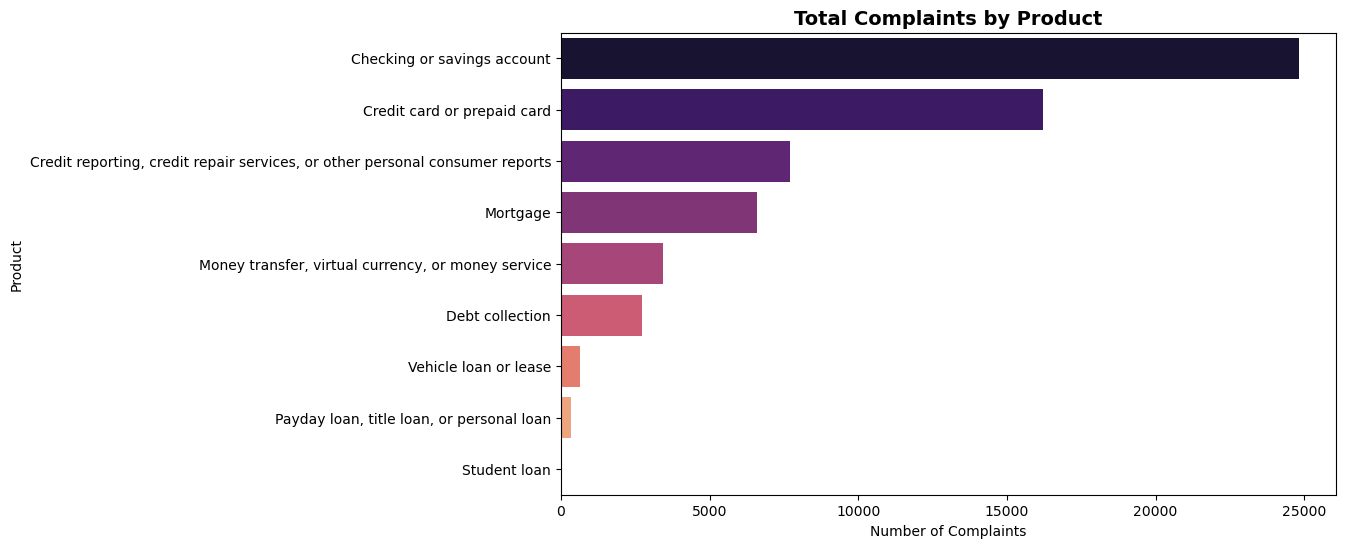

In [78]:
product_counts = df['Product'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=product_counts.values, 
            y=product_counts.index, 
            hue=product_counts.index, 
            palette=BLACK_THEME['bar_palette'],
            legend=False)
plt.title('Total Complaints by Product',fontsize=14, fontweight='bold')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.show()

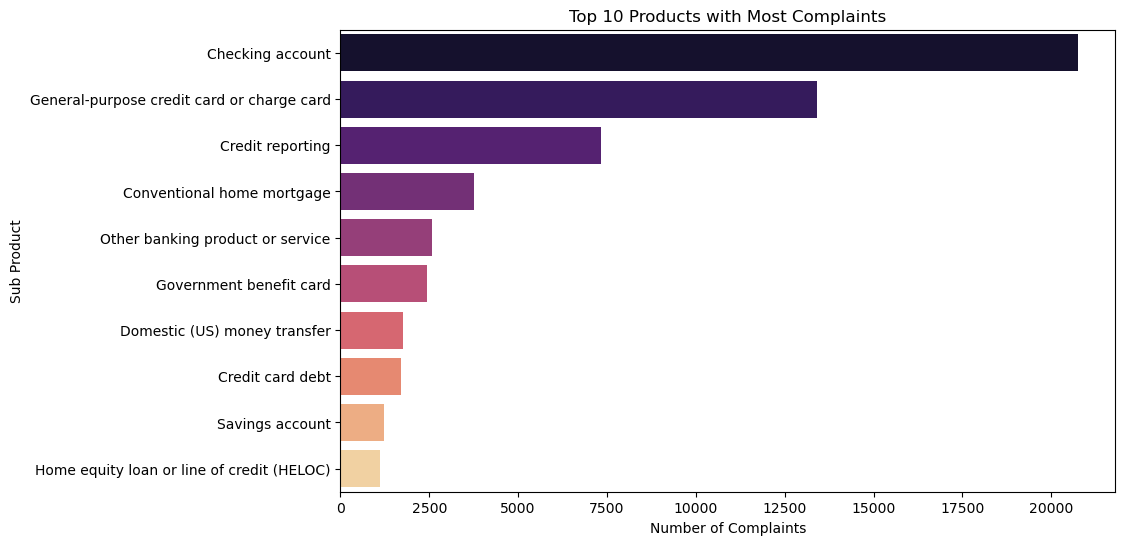

In [7]:
sub_product_counts = df['Sub-product'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x= sub_product_counts.values, 
            y= sub_product_counts.index,
            hue= sub_product_counts.index,
            palette= BLACK_THEME['bar_palette'],
            legend= False)
plt.title('Top 10 Products with Most Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Sub Product')
plt.show()

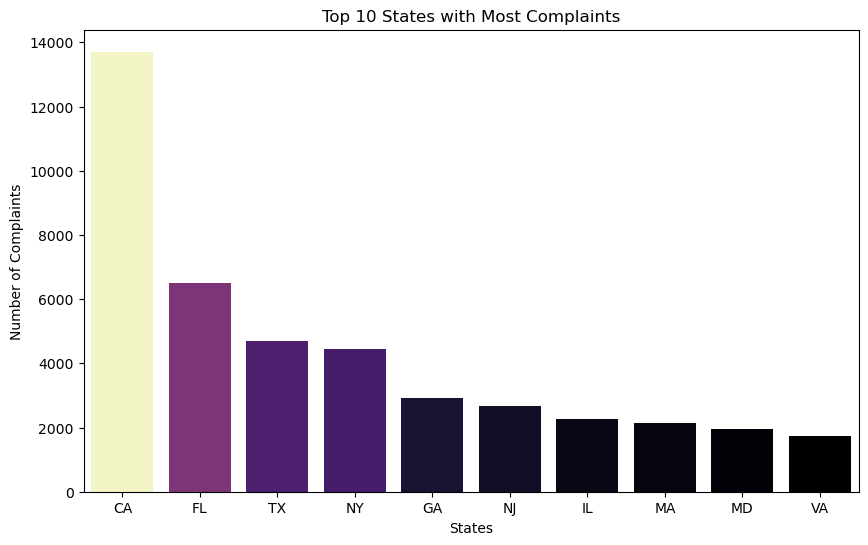

In [8]:
top_states = df['State'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x= top_states.index,
            y= top_states.values,
            hue= top_states.values,
            palette= BLACK_THEME['bar_palette'],
            legend= False)
plt.title('Top 10 States with Most Complaints')
plt.xlabel('States')
plt.ylabel('Number of Complaints')
plt.show()

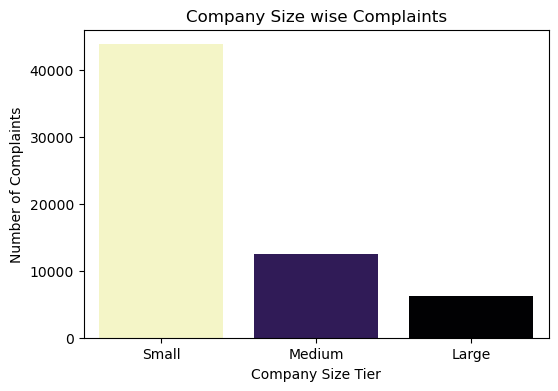

In [87]:
tier_wise_complaints= df['Company_Size_Tier'].value_counts()
plt.figure(figsize= (6,4))
sns.barplot(x= tier_wise_complaints.index,
             y= tier_wise_complaints.values,
             hue= tier_wise_complaints.values,
             palette= BLACK_THEME['bar_palette'],
             legend= False)
plt.title('Company Size wise Complaints')
plt.xlabel('Company Size Tier')
plt.ylabel('Number of Complaints')
plt.show()

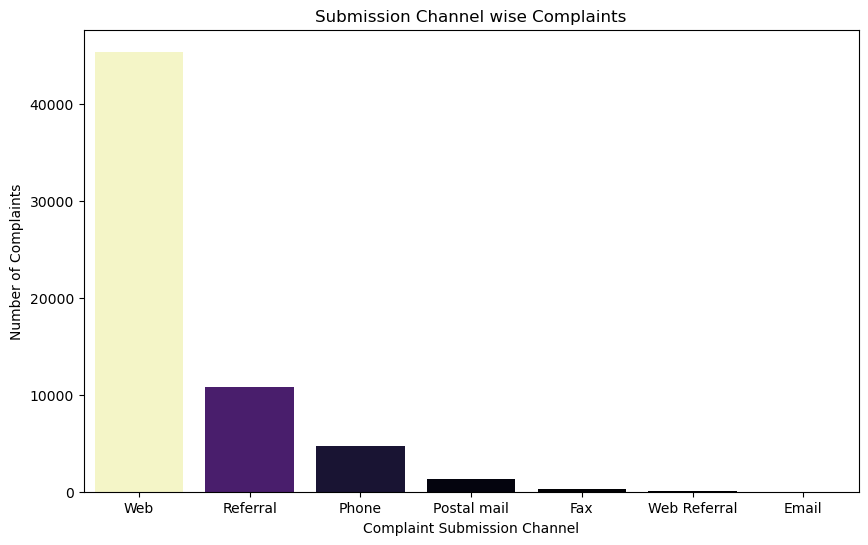

In [10]:
complaint_submission_channel = df['Submitted via'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x= complaint_submission_channel.index,
            y= complaint_submission_channel.values,
            hue= complaint_submission_channel.values,
            palette= BLACK_THEME['bar_palette'],
            legend= False)
plt.title('Submission Channel wise Complaints')
plt.xlabel('Complaint Submission Channel')
plt.ylabel('Number of Complaints')
plt.show()

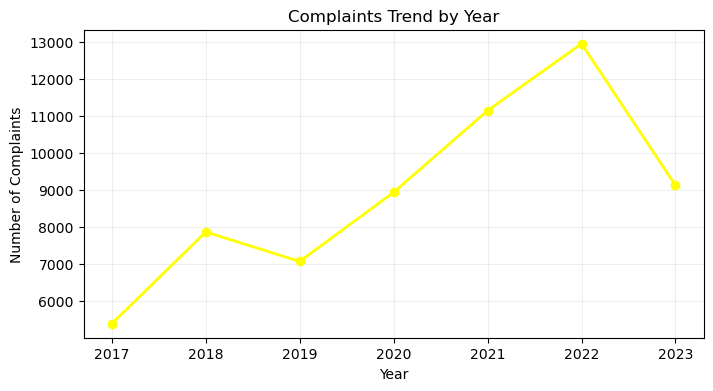

In [88]:
yearly_counts = df.groupby(df['Date submitted'].dt.year).size()
plt.figure(figsize=(8,4))
yearly_counts.plot(kind='line', marker='o', color=BLACK_THEME['accent_primary'], linewidth=2)
plt.title('Complaints Trend by Year')
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.grid(True, alpha=0.2)
plt.show()

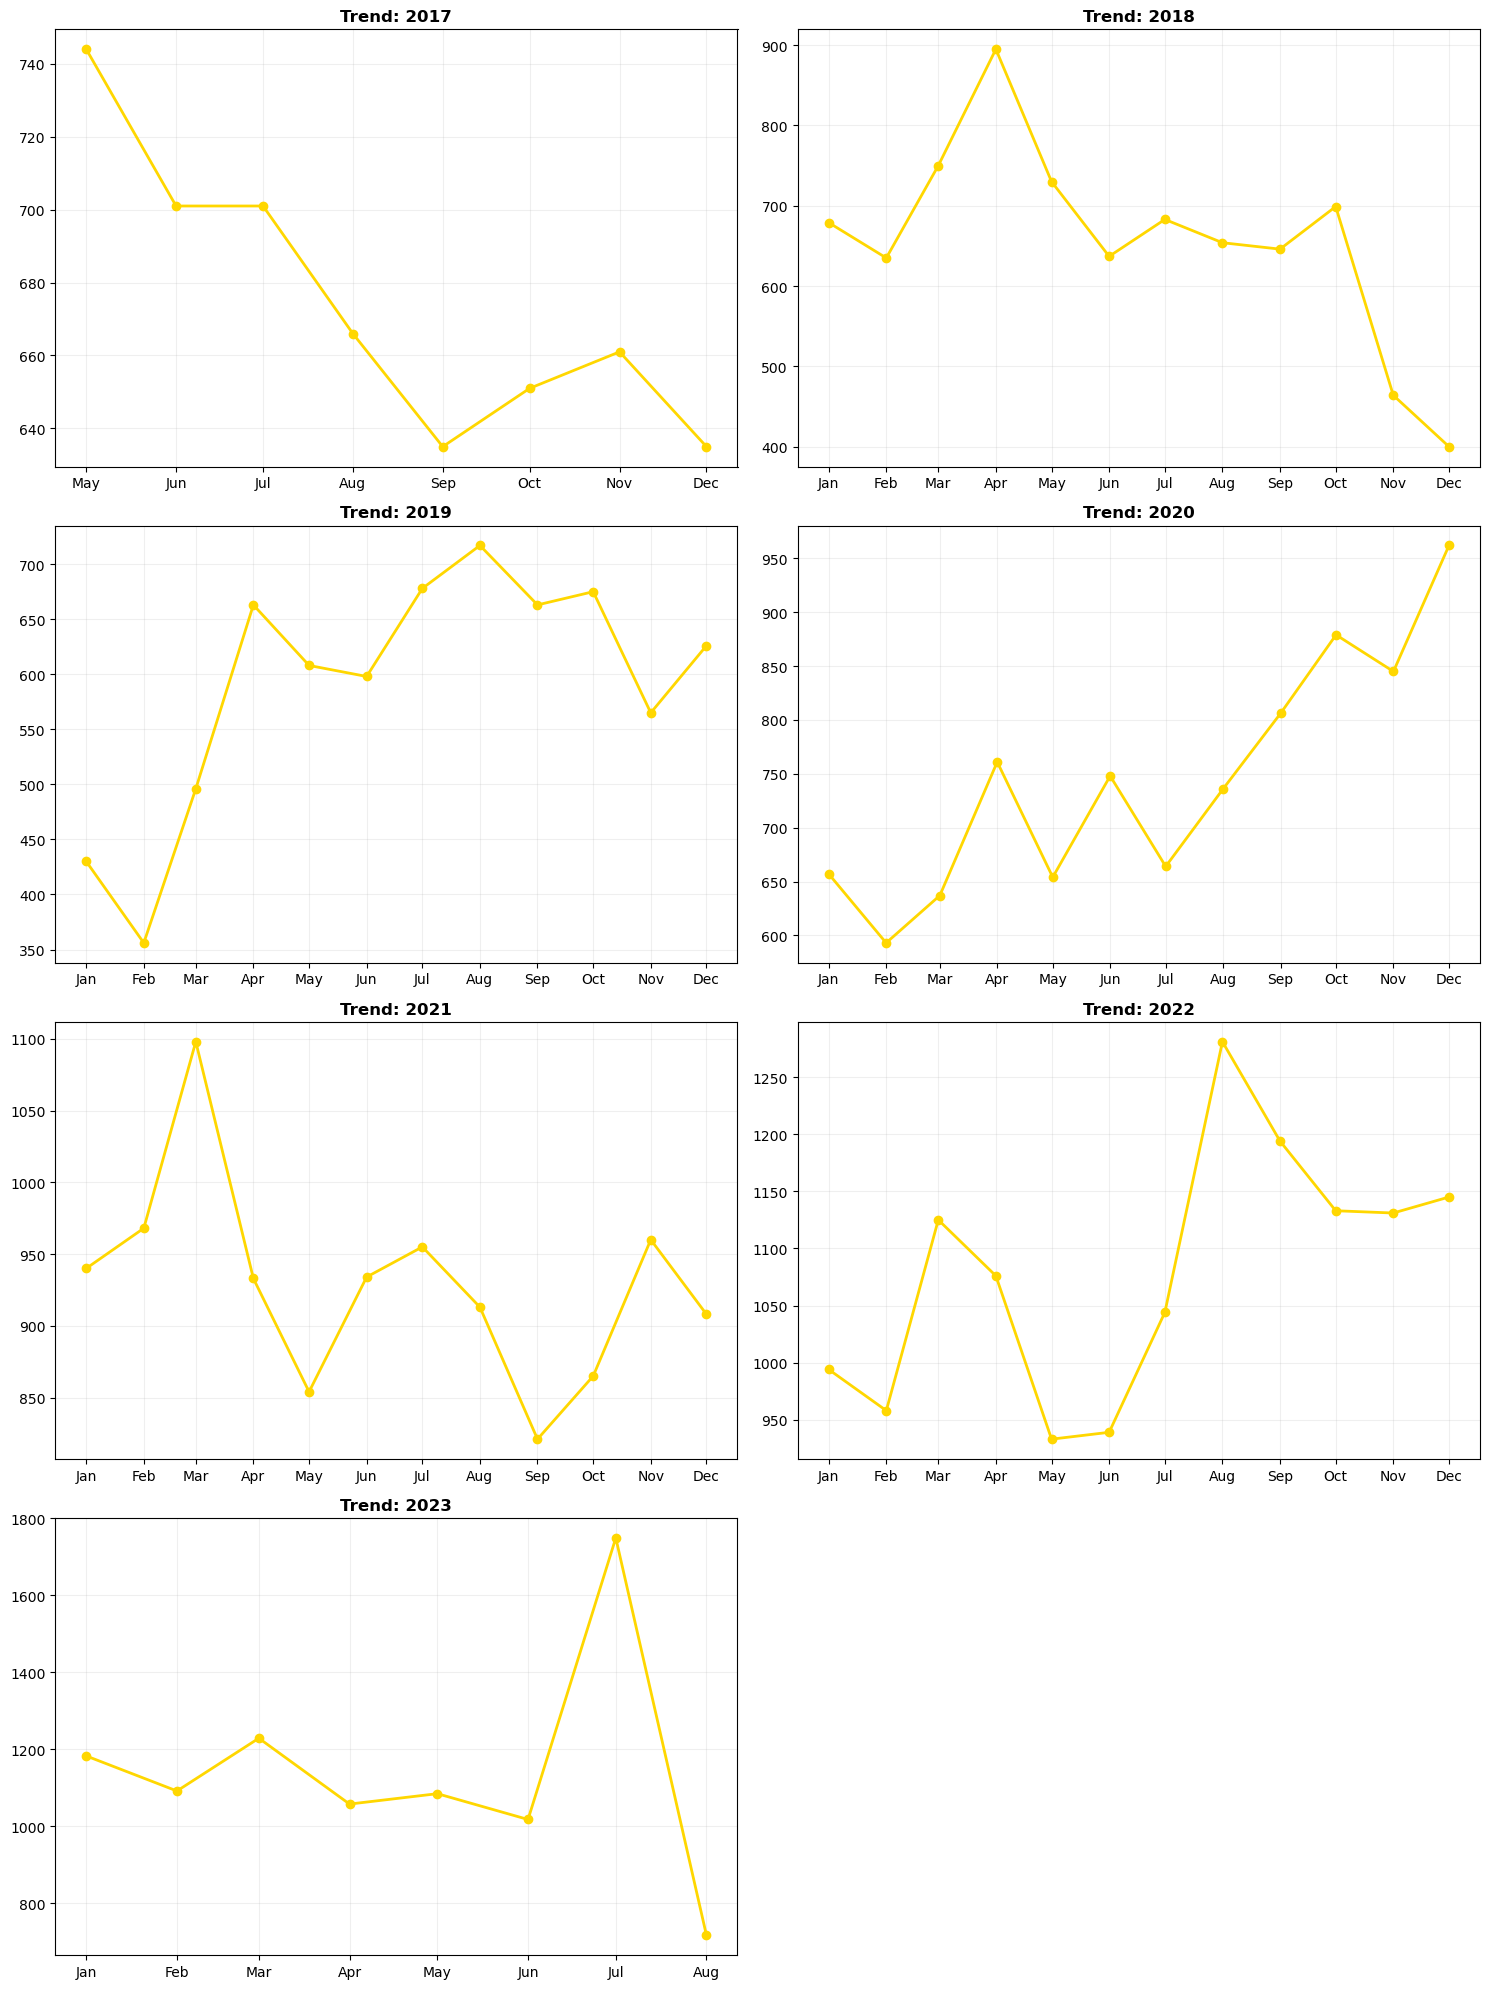

In [49]:
unique_years = sorted(df['Year'].unique())
num_years = len(unique_years)
num_rows = math.ceil(num_years / 2)
fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
axes_flat = axes.flatten()

for i, year in enumerate(unique_years):
    yearly_data = df[df['Year'] == year]
    trend = yearly_data.groupby(yearly_data['Date submitted'].dt.to_period('M')).size().reset_index()
    trend.columns = ['Month', 'Count']
    trend['Month'] = trend['Month'].dt.to_timestamp()
    
    axes_flat[i].plot(trend['Month'], trend['Count'], marker='o', color=BLACK_THEME['accent_primary'], linewidth=2)
    
    axes_flat[i].set_title(f'Trend: {year}', fontsize=12, fontweight='bold')
    axes_flat[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axes_flat[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes_flat[i].grid(True, alpha=0.2)

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

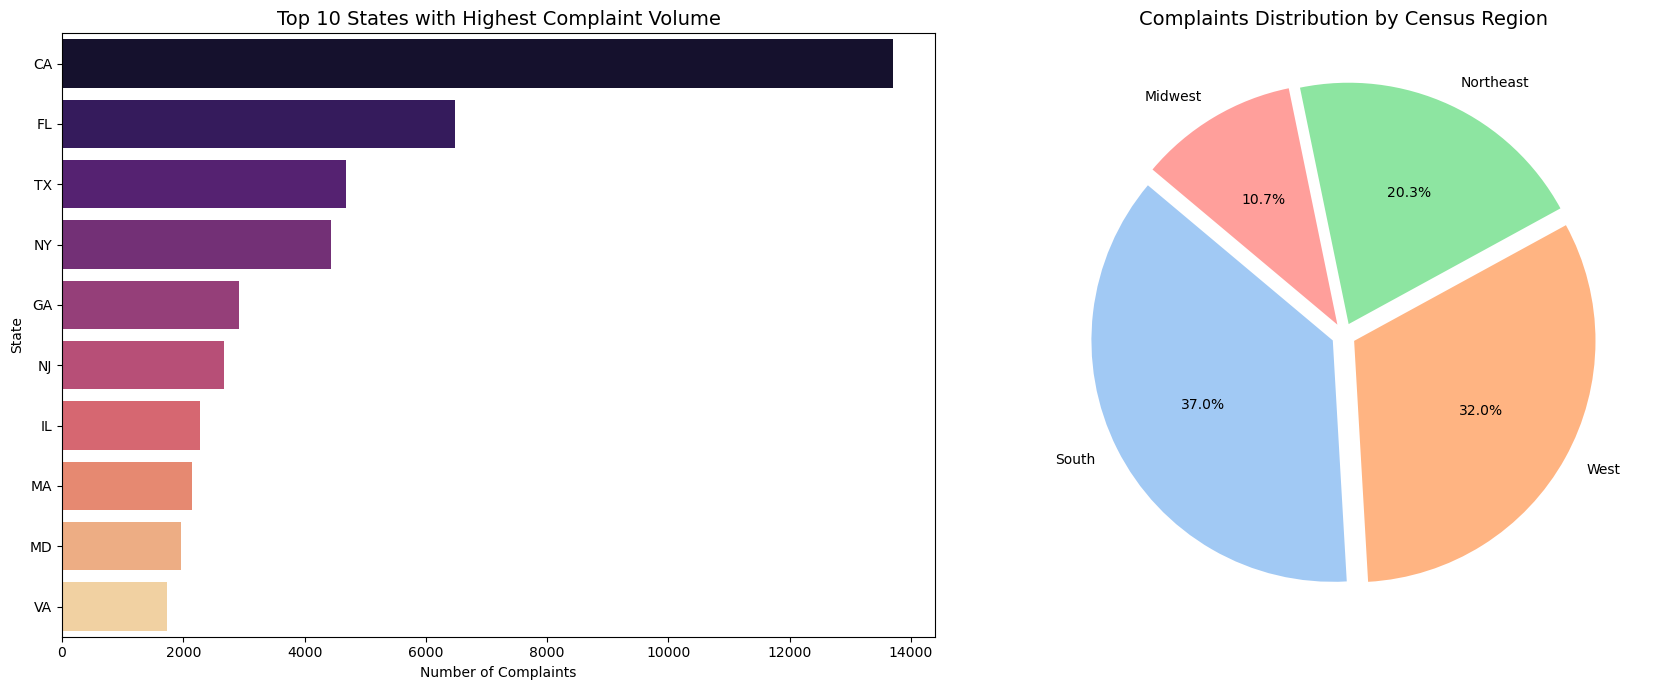

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

state_counts = df['State'].value_counts().head(10)
sns.barplot(
    x=state_counts.values, 
    y=state_counts.index, 
    hue=state_counts.index,
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[0],
    legend=False)
ax[0].set_title('Top 10 States with Highest Complaint Volume', fontsize=14)
ax[0].set_xlabel('Number of Complaints')

region_counts = df['Census_Region'].value_counts()
ax[1].pie(
    region_counts, 
    labels=region_counts.index, 
    autopct='%1.1f%%', 
    colors=BLACK_THEME['bar_palette'],
    startangle=140,
    explode=[0.05] * len(region_counts))
ax[1].set_title('Complaints Distribution by Census Region', fontsize=14)

plt.tight_layout()
plt.show()

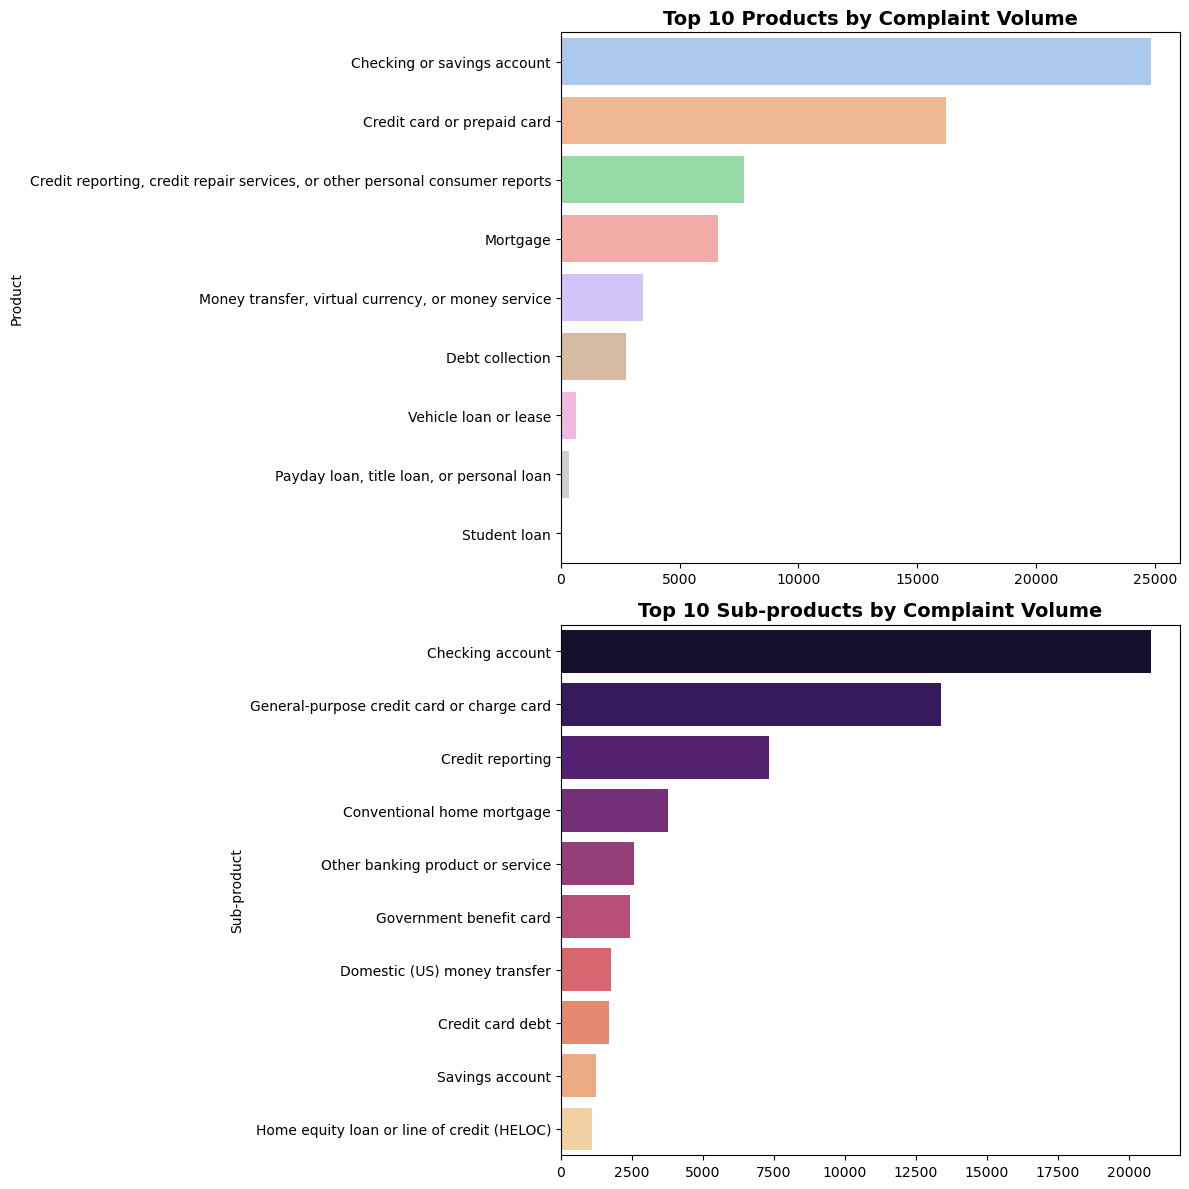

In [60]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

prod_counts = df['Product'].value_counts().head(10)
sns.barplot(
    x=prod_counts.values, 
    y=prod_counts.index, 
    hue=prod_counts.index, 
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[0], 
    legend=False)
ax[0].set_title('Top 10 Products by Complaint Volume', fontsize=14, fontweight='bold')

sub_prod_counts = df['Sub-product'].value_counts().head(10)
sns.barplot(
    x=sub_prod_counts.values, 
    y=sub_prod_counts.index, 
    hue=sub_prod_counts.index, 
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[1], 
    legend=False)
ax[1].set_title('Top 10 Sub-products by Complaint Volume', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

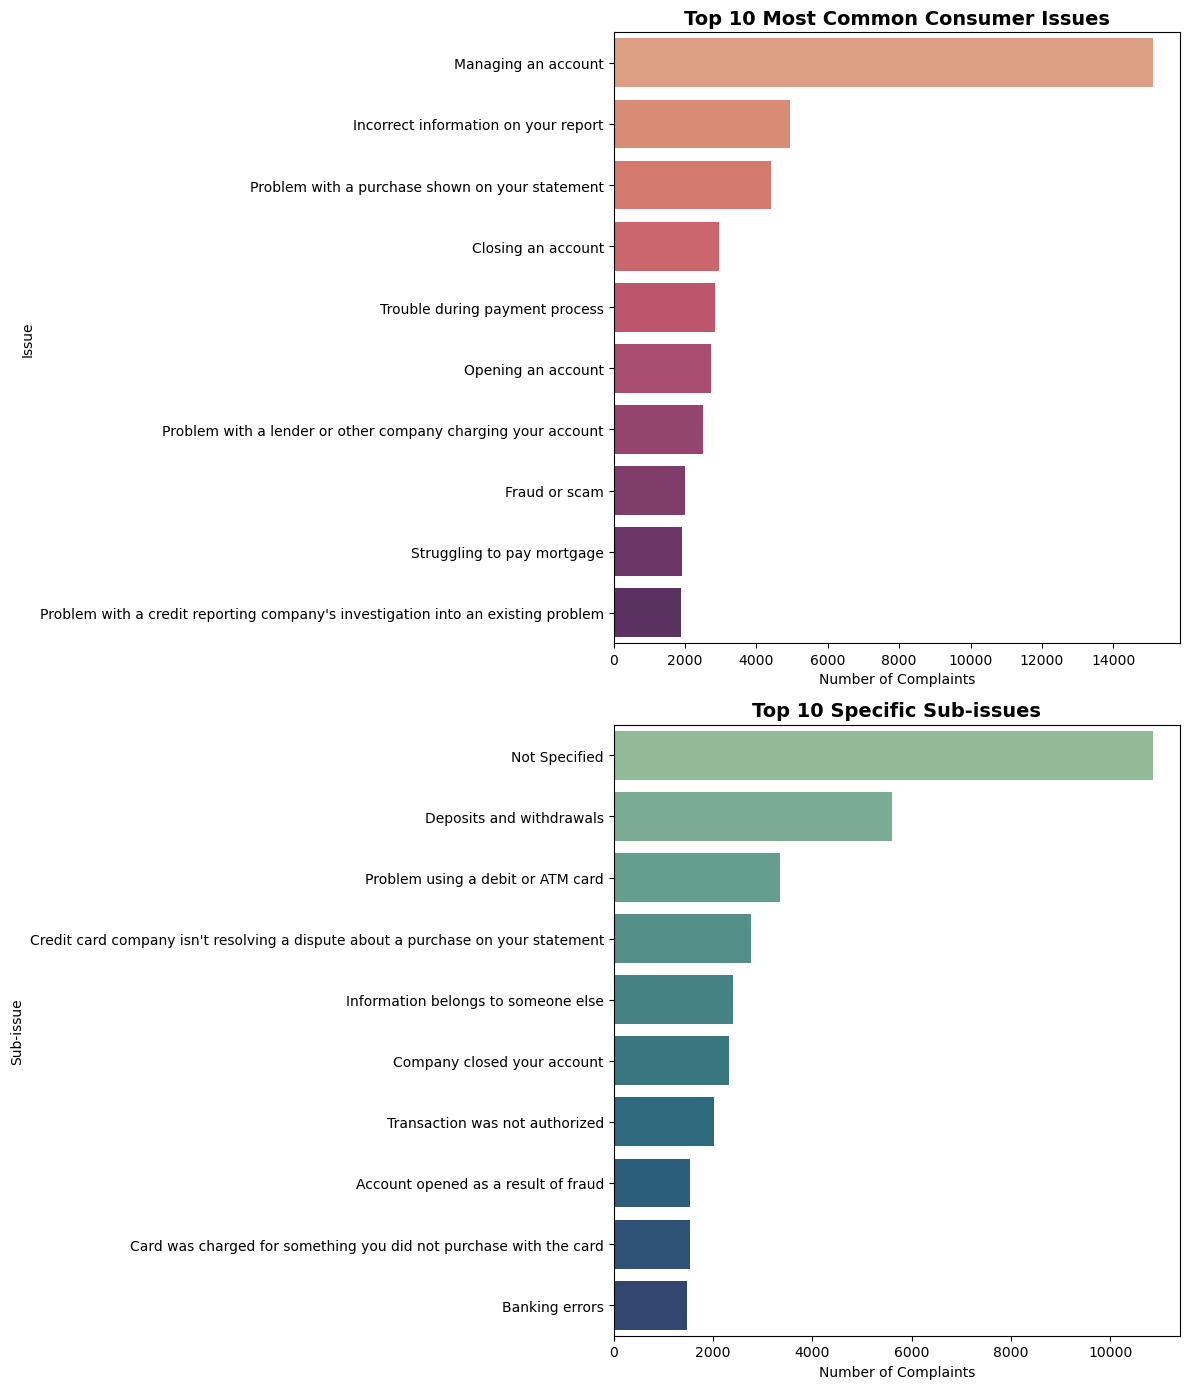

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(12, 14))

top_issues = df['Issue'].value_counts().head(10)
sns.barplot(
    x=top_issues.values, 
    y=top_issues.index, 
    hue=top_issues.index,
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[0],
    legend=False)
ax[0].set_title('Top 10 Most Common Consumer Issues', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Number of Complaints')

top_sub_issues = df['Sub-issue'].value_counts().head(10)
sns.barplot(
    x=top_sub_issues.values, 
    y=top_sub_issues.index, 
    hue=top_sub_issues.index,
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[1],
    legend=False)
ax[1].set_title('Top 10 Specific Sub-issues', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Number of Complaints')

plt.tight_layout()
plt.show()

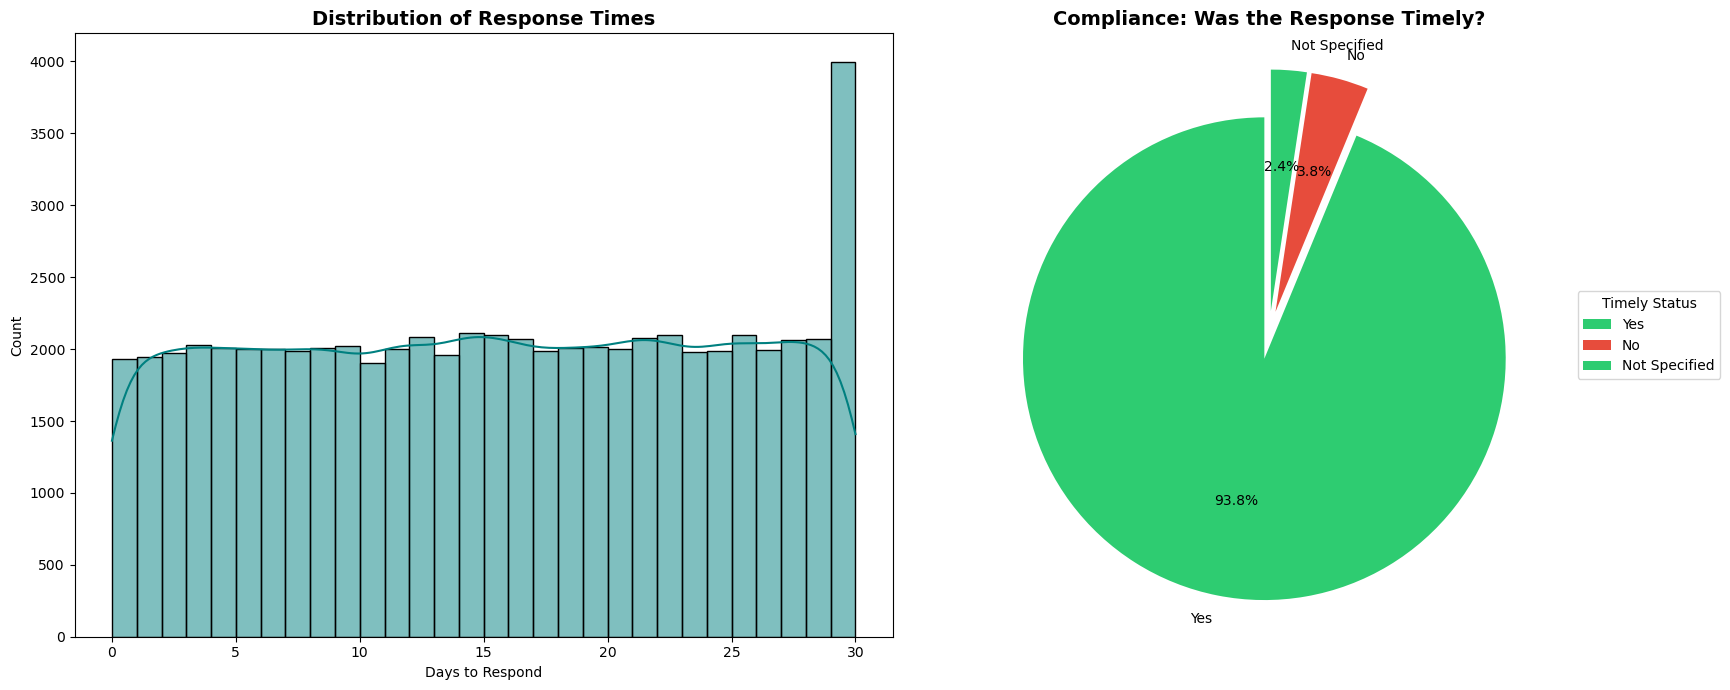

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(df['Response_Time_Days'], bins=30, kde=True, color=BLACK_THEME['accent_cyan'], ax=ax[0])
ax[0].set_title('Distribution of Response Times', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Days to Respond')
timely_counts = df['Timely response?'].value_counts()
current_explode = [0.1] * len(timely_counts) if len(timely_counts) > 0 else None


wedges, texts, autotexts = ax[1].pie(
    timely_counts, 
    labels=timely_counts.index, 
    autopct='%1.1f%%', 
    colors=[BLACK_THEME['accent_primary'], BLACK_THEME['accent_red']], 
    startangle=90,
    explode=current_explode if len(timely_counts) > 1 else None)


ax[1].legend(
    wedges, 
    timely_counts.index,
    title="Timely Status",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1))

ax[1].set_title('Compliance: Was the Response Timely?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

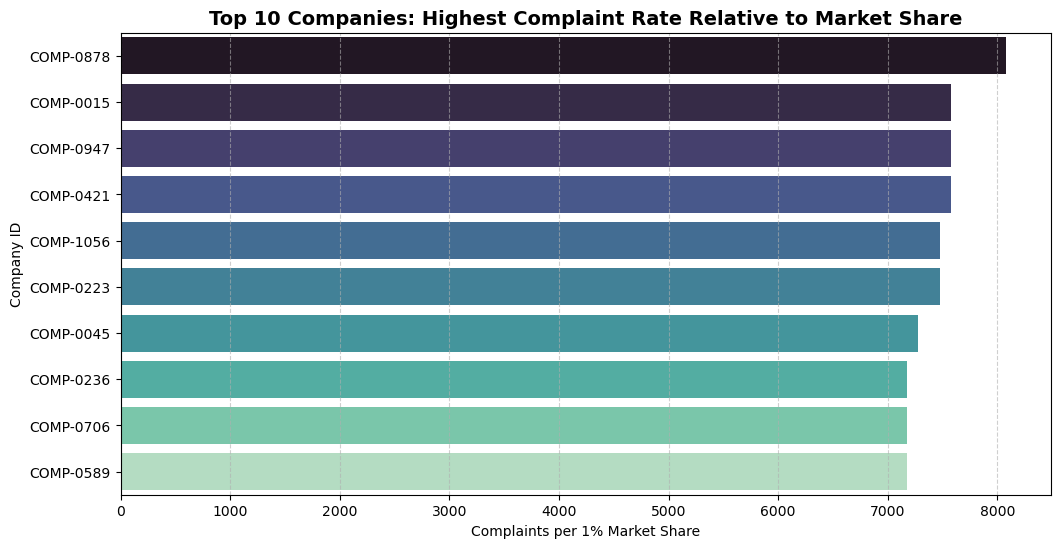

In [77]:
market_outliers = df.groupby('Company_ID_1081')['Complaints_per_1pct_Share'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=market_outliers.values, 
    y=market_outliers.index.astype(str), # Ensure ID is a string for the axis
    hue=market_outliers.index.astype(str),
    palette=BLACK_THEME['bar_palette'],
    legend=False)

plt.title('Top 10 Companies: Highest Complaint Rate Relative to Market Share', fontsize=14, fontweight='bold')
plt.xlabel('Complaints per 1% Market Share')
plt.ylabel('Company ID')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

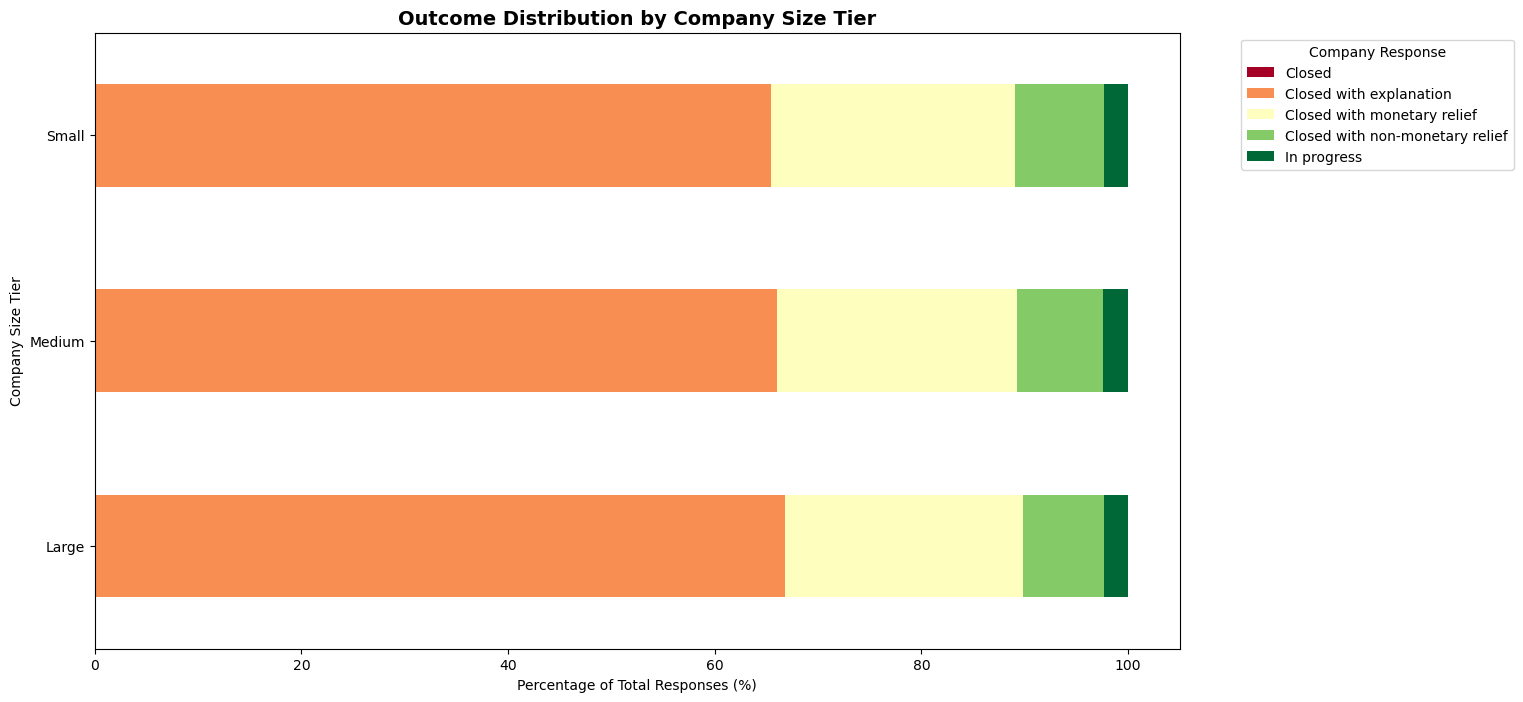

In [80]:
size_outcome_map = pd.crosstab(df['Company_Size_Tier'], df['Company response to consumer'], normalize='index') * 100

size_outcome_map.plot(kind='barh', stacked=True, figsize=(14, 8), color=BLACK_THEME['bar_palette'])

plt.title('Outcome Distribution by Company Size Tier', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Responses (%)')
plt.ylabel('Company Size Tier')
plt.legend(title='Company Response', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

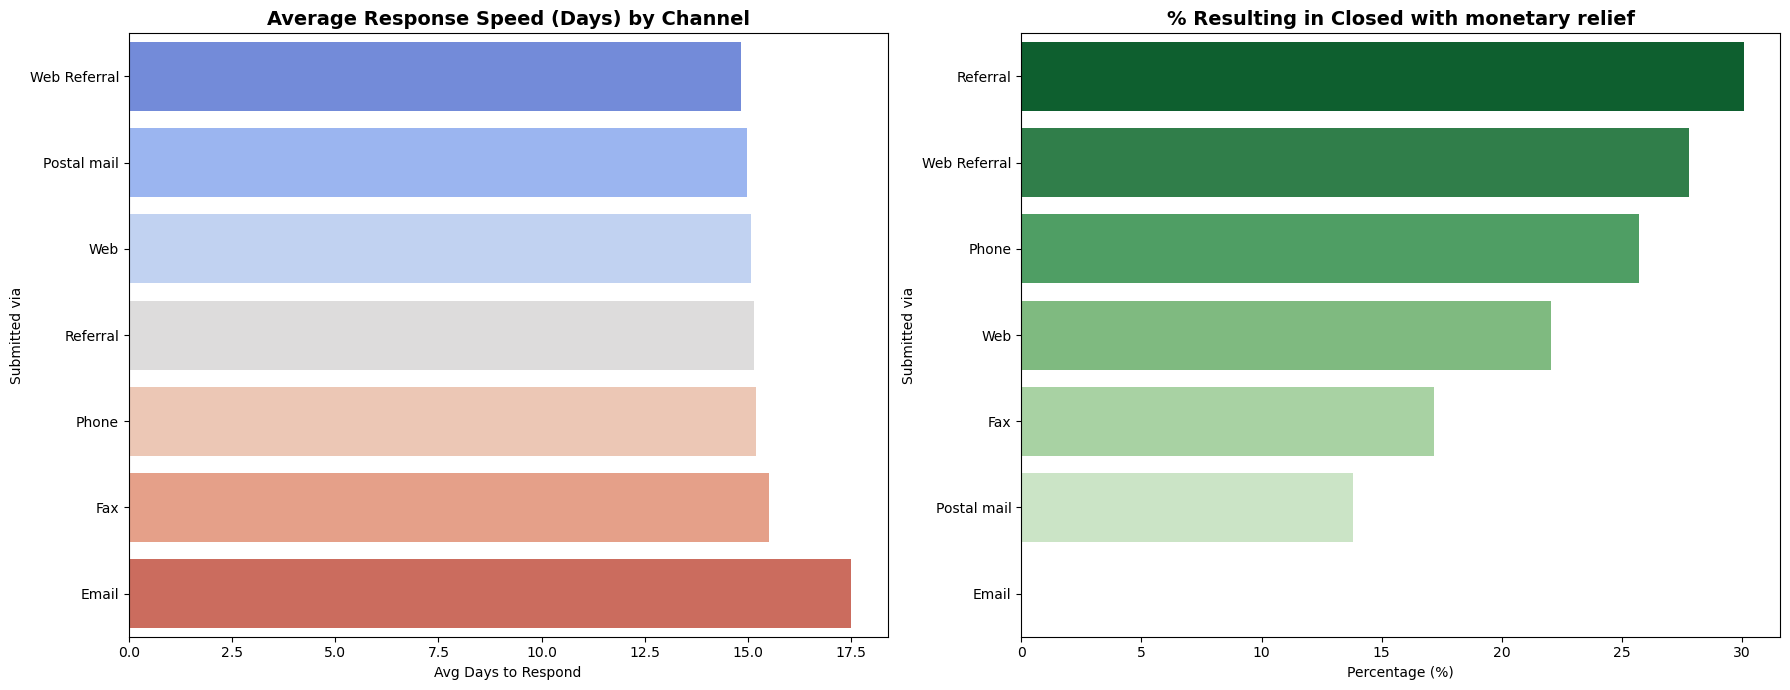

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

channel_speed = df.groupby('Submitted via')['Response_Time_Days'].mean().sort_values()
sns.barplot(
    x=channel_speed.values, 
    y=channel_speed.index, 
    hue=channel_speed.index,
    palette=BLACK_THEME['bar_palette'], 
    ax=ax[0],
    legend=False)
ax[0].set_title('Average Response Speed (Days) by Channel', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Avg Days to Respond')

relief_col = [col for col in df['Company response to consumer'].unique() if 'monetary relief' in str(col).lower()]

if relief_col:
    target_col = relief_col[0]
    relief_map = pd.crosstab(df['Submitted via'], df['Company response to consumer'], normalize='index')
    
    monetary_relief = (relief_map[target_col] * 100).sort_values(ascending=False)
    
    sns.barplot(
        x=monetary_relief.values, 
        y=monetary_relief.index, 
        hue=monetary_relief.index,
        palette=BLACK_THEME['bar_palette'], 
        ax=ax[1],
        legend=False )
    ax[1].set_title(f'% Resulting in {target_col}', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Percentage (%)')
else:
    print("Warning: No column containing 'monetary relief' was found.")

plt.tight_layout()
plt.show()